Case 2 Test A/B 

Has recibido una tarea analítica de una tienda en línea internacional. Tus predecesores no consiguieron completarla: lanzaron una prueba A/B y luego abandonaron (para iniciar una granja de sandías en Brasil). Solo dejaron las especificaciones técnicas y los resultados de las pruebas.

PASO 1 - Preparación de Datos

In [ ]:
#importar librerías 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import zscore


In [51]:
# cargar datasets
marketing_events = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case2_ab_testing\data\raw\ab_project_marketing_events_us.csv')
new_users = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case2_ab_testing\data\raw\final_ab_new_users_upd_us.csv')
events = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case2_ab_testing\data\raw\final_ab_events_upd_us.csv')
participants = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case2_ab_testing\data\raw\final_ab_participants_upd_us.csv') 


Revisar Datasets

In [52]:
# Revisión - Primer dataset

marketing_events.info()


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


Obs en df marketing: 

tipo: Se debe convertir las columnas de fechas (la 2 y la 3) a tipo datetime para poder hacer cálculos de duración o filtros:

In [53]:
# son convertidas las dos columas de fechas a tipo datetime

marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

In [54]:
# verificación del cambio ok

marketing_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     str           
 1   regions    14 non-null     str           
 2   start_dt   14 non-null     datetime64[us]
 3   finish_dt  14 non-null     datetime64[us]
dtypes: datetime64[us](2), str(2)
memory usage: 580.0 bytes


In [55]:
# Revisión - Segundo Dataset

new_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     58703 non-null  str  
 1   first_date  58703 non-null  str  
 2   region      58703 non-null  str  
 3   device      58703 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB


Obs: 

1. tipo: en df new_users, también debe convertida first_date a datetime
2. Duplicados: 0, no hay user_id duplicados      

In [56]:
# conversión de columna first_date a tipo datetime
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

In [57]:
# verificación del cambio
new_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  str           
 1   first_date  58703 non-null  datetime64[us]
 2   region      58703 non-null  str           
 3   device      58703 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 1.8 MB


In [58]:
# Revisión del Tercer Dataset

events.info()

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB


In [59]:
# revisión de la columna details
print(events['details'])

0         99.99
1          9.99
2          4.99
3          4.99
4          4.99
          ...  
423756      NaN
423757      NaN
423758      NaN
423759      NaN
423760      NaN
Name: details, Length: 423761, dtype: float64


Obs en df events: 
1. Tipo: La columna event_dt, debe ser convertida a datetime
2. NaN: La columna details, presenta un alto número de NaNs, pero por ahora se dejan tal cual

In [60]:
# conversion de la columna event_dt a tipo datetime

events['event_dt'] = pd.to_datetime(events['event_dt'])

In [61]:
# confirmación del cambio
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  str           
 1   event_dt    423761 non-null  datetime64[us]
 2   event_name  423761 non-null  str           
 3   details     60314 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 12.9 MB


In [62]:
# Revisión cuarto Dataset

participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB


Obs: Dataset participants limpio, pero CON duplicados

PASO 2 - Análisis Inicial

2.1 Comparar tamaños de muestra

In [63]:
# Revisar distribución inicial de usuarios por grupo

participants['group'].value_counts()

group
A    8214
B    6311
Name: count, dtype: int64

Obs: Inicialmente, se identifica al grupo A con el 57% de participación, respecto al 43% en el B, pero estos porcentajes cambiarán ya que hay usuarios duplicados.

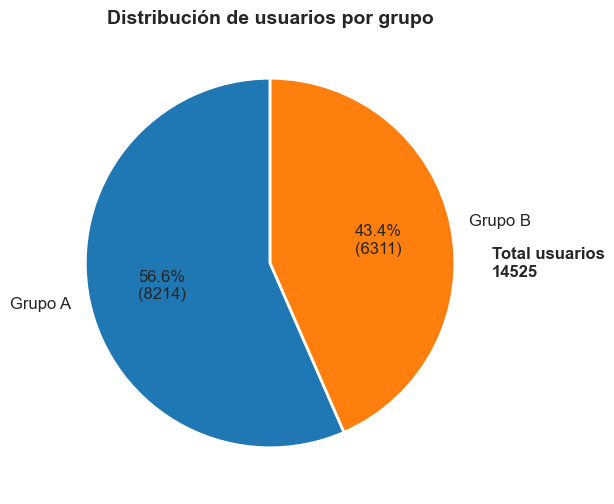

In [123]:
# Distribución inicial de los usuarios por grupo

# Datos
labels = ['Grupo A', 'Grupo B']
values = [8214, 6311]
total = sum(values)

# Función para % + valor
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return inner

fig, ax = plt.subplots(figsize=(8,6))

# Gráfico de torta
ax.pie(
    values,
    labels=labels,
    autopct=autopct_format(values),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Título
ax.set_title('Distribución de usuarios por grupo', fontsize=14, fontweight='bold')

# 🔥 Total al lado
plt.text(
    1.2, 0,  # posición (derecha del gráfico)
    f'Total usuarios\n{total}',
    fontsize=12,
    fontweight='bold',
    va='center'
)

plt.show()

In [64]:
# Revisar duplicados por usuario

duplicates = participants['user_id'].duplicated().sum()
total_users = participants['user_id'].nunique()

percentage = (duplicates / total_users)* 100

print(f" Total de usuarios únicos:{total_users}, Usuarios duplicados: {duplicates} ({percentage:.2f}%)")

 Total de usuarios únicos:13638, Usuarios duplicados: 887 (6.50%)


Obs:
Casi el 7% de los usuarios están presentes en ambos grupos (A y B)

2.2 Distribución de usuarios por grupo

In [65]:
# verificar en qué lugar están ubicados los duplicados 
duplicates_group = participants[participants['user_id'].duplicated(keep=False)]

# ver en qué grupo estan
duplicates_group.groupby('user_id')['group'].nunique().value_counts()                             
                               


group
1    446
2    441
Name: count, dtype: int64

Obs: 441 usuarios contaminados, ya que están presentes en A y B y deben ser eliminados según el principio fundamental de A/B testing acerca de que un usuario debe estar expuesto a una sola versión para que la prueba sea confiable.

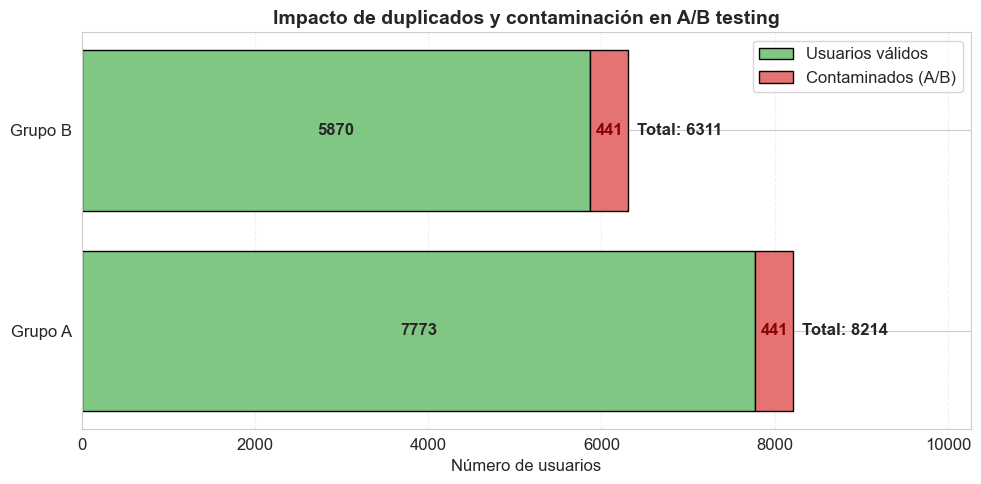

In [ ]:
# Impacto de duplicados y contaminados


# Datos
A_total = 8214
B_total = 6311
contaminados = 441
duplicados_totales = 881

A_clean = A_total - contaminados
B_clean = B_total - contaminados

labels = ['Grupo A', 'Grupo B']

plt.figure(figsize=(10,5))

# Barras limpias
plt.barh(labels, [A_clean, B_clean],
         color='#81c784', edgecolor='black', label='Usuarios válidos')

# Parte contaminada
plt.barh(labels, [contaminados, contaminados],
         left=[A_clean, B_clean],
         color='#e57373', edgecolor='black', label='Contaminados (A/B)')

# Etiquetas dentro de barras
plt.text(A_clean/2, 0, f'{A_clean}', va='center', ha='center', fontweight='bold')
plt.text(B_clean/2, 1, f'{B_clean}', va='center', ha='center', fontweight='bold')

plt.text(A_clean + contaminados/2, 0, f'{contaminados}', 
         va='center', ha='center', color='darkred', fontweight='bold')

plt.text(B_clean + contaminados/2, 1, f'{contaminados}', 
         va='center', ha='center', color='darkred', fontweight='bold')

# Totales
plt.text(A_total + 100, 0, f'Total: {A_total}', va='center', fontweight='bold')
plt.text(B_total + 100, 1, f'Total: {B_total}', va='center', fontweight='bold')

# 🔥 Anotación clave (LOS 881)
plt.annotate(
    f'881 duplicados detectados\n441 contaminan el experimento',
    xy=(max(A_total, B_total)*0.6, 1.5),
    xytext=(max(A_total, B_total)*0.6, 2),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray")
)

# Estilo
plt.title('Impacto de duplicados y contaminación en A/B testing',
          fontsize=14, fontweight='bold')

plt.xlabel('Número de usuarios')
plt.xlim(0, max(A_total, B_total) * 1.25)

plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Obs: Aunque se identificaron 881 duplicados en el dataset, solo 441 corresponden a usuarios presentes en ambos grupos, lo que introduce contaminación y compromete la validez del experimento

Eliminación de duplicados

In [66]:
#1 Identificar usuarios contaminados

# usuarios en ambos grupos
bad_users = duplicates_group.groupby('user_id')['group'].nunique()
bad_users = bad_users[bad_users > 1].index

In [67]:
#2. Eliminarlos completamente

participants_clean = participants[~participants['user_id'].isin(bad_users)]

In [68]:
#3. Eliminar duplicados restantes
participants_clean = participants_clean.drop_duplicates(subset='user_id')

In [69]:
#4. Verificar tamaños de muestra nuevamente
participants_clean['group'].value_counts()

group
A    7433
B    5764
Name: count, dtype: int64

Obs: Con estos usuarios se llevará a cabo la prueba, pero antes, será analizada la distribución de eventos por usuario y por día 

<function matplotlib.pyplot.show(close=None, block=None)>

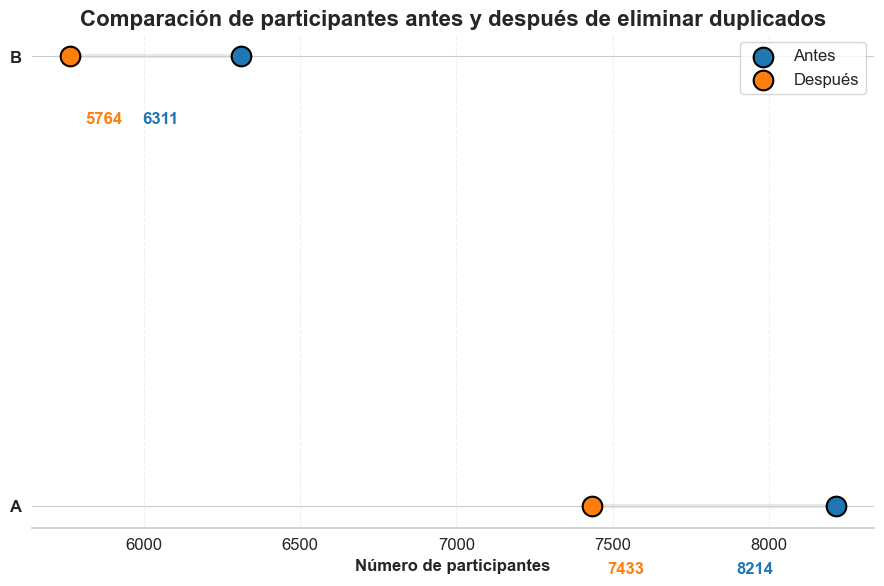

In [ ]:
# Visualización de grupos antes y después de eliminar usuarios duplicados
# Datos
labels = ['A', 'B']
before = [8214, 6311]
after = [7433, 5764]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9,6))

# Gráfico tipo dumbbell
ax.hlines(y=x, xmin=before, xmax=after, color='lightgrey', alpha=0.5, linewidth=3)
ax.scatter(before, x, color='#1f77b4', s=200, label='Antes', edgecolors='black', linewidth=1.5, zorder=5)
ax.scatter(after, x, color='#ff7f0e', s=200, label='Después', edgecolors='black', linewidth=1.5, zorder=5)

# Etiquetas y títulos
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=12, fontweight='bold')
ax.set_xlabel('Número de participantes', fontsize=12, fontweight='bold')
ax.set_title('Comparación de participantes antes y después de eliminar duplicados', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)

# Añadir valores sobre los puntos con ajuste vertical para no superponerse
for i in range(len(labels)):
    ax.text(before[i]-200, x[i]-0.15, str(before[i]), color='#1f77b4', fontweight='bold', fontsize=12, ha='right')
    ax.text(after[i]+50, x[i]-0.15, str(after[i]), color='#ff7f0e', fontweight='bold', fontsize=12, ha='left')

# Mejorar estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show

2.2 Distribución de eventos por usuario y por día

Se verifica:

Primero: Si los usuarios generan una cantidad similar de eventos (A vs B)
Segundo: Cómo se comportan los eventos en el tiempo

2.2.1 Eventos por usuario

In [ ]:
# primero se realiza intersección entre df participants no repetidos y new_users
ab_data = participants_clean.merge(new_users, on='user_id', how='inner')

In [ ]:
# verificación del merge o intersección
ab_data.head()

,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


In [74]:
# segundo - Realizo intersección entre ab_data y events por usuario

ab_full_data = ab_data.merge(events, on='user_id', how='inner')

In [75]:
ab_full_data.head()

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,purchase,99.99
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:29,product_cart,NaN
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,product_page,NaN
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,login,NaN
4,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone,2020-12-20 15:46:06,product_page,NaN


In [ ]:
# Ahora si calculo la Distribución de eventos por usuario


# eventos por usuario
events_per_user = (
    ab_full_data.groupby('user_id')['event_name']
    .count()
    .reset_index()
)

events_per_user.columns = ['user_id', 'event_count']

# agregar grupo
events_per_user = events_per_user.merge(
    ab_full_data[['user_id', 'group']].drop_duplicates(),
    on='user_id',
    how='left'
)



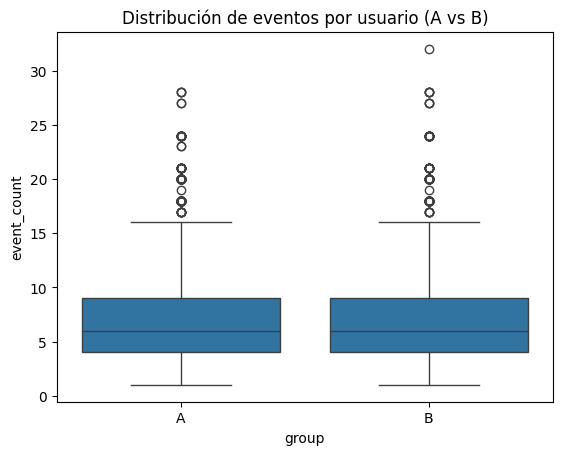

In [78]:
# Visualizar

sns.boxplot(data=events_per_user, x='group', y='event_count')
plt.title('Distribución de eventos por usuario (A vs B)')
plt.show()

Obs: La distribución del número de eventos por usuario es similar entre los grupos A y B, lo que indica que ambos presentan niveles de interacción comparables, reduciendo el riesgo de sesgo en el análisis del experimento.

2.2.2  Eventos por día

In [79]:
# Se crea la columna fecha del evento en el df ab_full_date

ab_full_data['event_date'] = ab_full_data['event_dt'].dt.date

In [80]:
ab_full_data.head()

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details,event_date
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,purchase,99.99,2020-12-07
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:29,product_cart,NaN,2020-12-07
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,product_page,NaN,2020-12-07
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,login,NaN,2020-12-07
4,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone,2020-12-20 15:46:06,product_page,NaN,2020-12-20


In [81]:
# Distribución de eventos por día

events_per_day = (
    ab_full_data.groupby(['event_date', 'group'])['event_name']
    .count()
    .reset_index()
)

events_per_day.columns = ['event_date', 'group', 'event_count']

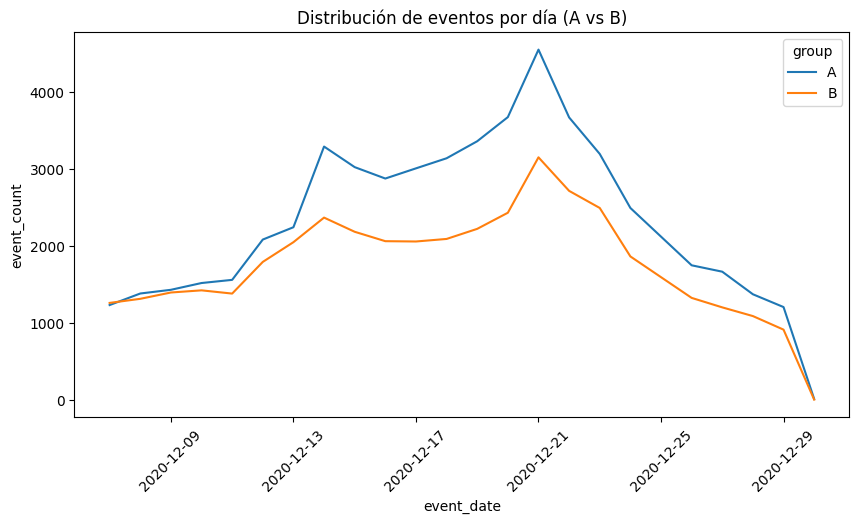

In [82]:
# representación gráfiica de eventos por día
plt.figure(figsize=(10,5))

sns.lineplot(data=events_per_day, x='event_date', y='event_count', hue='group')

plt.title('Distribución de eventos por día (A vs B)')
plt.xticks(rotation=45)
plt.show()

Obs: La distribución temporal de los eventos muestra patrones similares entre ambos grupos, con un incremento notable en la actividad alrededor de fechas cercanas a eventos comerciales, seguido de una disminución hacia el final del periodo. 

No se observan anomalías significativas que afecten de forma diferencial a los grupos.

2.3 Definición del universo elegible

In [ ]:
# Filtramos participantes de la EU entre 7 y 21 de dic del 2020

eligible_users = new_users[
    (new_users['region'] == 'EU') &
    (new_users['first_date'] >= '2020-12-07') &
    (new_users['first_date'] <= '2020-12-21')
]

ratio = participants_clean['user_id'].nunique() / eligible_users['user_id'].nunique()
print(ratio)

0.33438909441037856


Obs: La proporción de usuarios en el experimento (~33%) supera significativamente el 15% esperado, lo que indica una posible desviación en la asignación de tráfico.

Ultimas validacion de los participantes, antes del embudo

In [ ]:
# Ver si A y B son comparables en características

ab_data.groupby('group')['device'].value_counts(normalize=True)

group  device 
A      Android    0.440105
       PC         0.260202
       iPhone     0.207108
       Mac        0.092584
B      Android    0.465177
       PC         0.243101
       iPhone     0.206307
       Mac        0.085414
Name: proportion, dtype: float64

Obs: La distribución por dispositivo es homogénea entre los grupos A y B, por lo que no se identifica sesgo por tipo de dispositivo que pueda afectar la comparación del experimento.

In [ ]:
# Distribución por fecha de registro

ab_data.groupby(['group', 'first_date'])['user_id'].nunique().unstack(0)

group,A,B
first_date,,
2020-12-07,128,148
2020-12-08,81,37
2020-12-09,69,66
2020-12-10,51,29
2020-12-11,77,15
2020-12-12,54,45
2020-12-13,45,12
2020-12-14,321,60
2020-12-15,177,27


Obs: Se observa un desbalance significativo en la distribución temporal de usuarios entre los grupos, con una mayor concentración en el grupo A. Esto podría introducir sesgos en los resultados, ya que el comportamiento de los usuarios puede variar según la fecha de registro.

In [ ]:
# verificar eventos mínimos por grupo

ab_full_data.groupby(['group', 'event_name'])['user_id'].nunique()

group  event_name  
A      login           7432
       product_cart    2357
       product_page    4937
       purchase        2555
B      login           5763
       product_cart    1911
       product_page    3715
       purchase        1881
Name: user_id, dtype: int64

Obs: Ambos grupos presentan todos los eventos clave del embudo (login, product_page, product_cart y purchase), lo que confirma que el funnel puede ser construido y comparado correctamente entre A y B.

PASO 3 - Construcción del embudo (product_page → product_cart → purchase)

In [95]:
# Usuarios únicos por evento y grupo

funnel = ab_full_data.groupby(['group', 'event_name'])['user_id'].nunique().reset_index()
funnel

,group,event_name,user_id
0,A,login,7432
1,A,product_cart,2357
2,A,product_page,4937
3,A,purchase,2555
4,B,login,5763
5,B,product_cart,1911
6,B,product_page,3715
7,B,purchase,1881


Obs: El grupo A tiene más usuarios en todas las etapas que B, lo que refleja un desbalance inicial entre los grupos, algo a tener en cuenta al interpretar resultados.

In [98]:
# Pivotear para ver el funnel claro

funnel_pivot = funnel.pivot(index='group', columns='event_name', values='user_id')
funnel_pivot

event_name,login,product_cart,product_page,purchase
group,,,,
A,7432,2357,4937,2555
B,5763,1911,3715,1881


Obs: El embudo muestra caídas en cada transición: login → product_page → product_cart → purchase. La pérdida más fuerte en ambos grupos ocurre al pasar de product_page a product_cart.

In [ ]:
# Calcular conversiones

funnel_pivot['conv_page_to_cart'] = funnel_pivot['product_cart'] / funnel_pivot['product_page']
funnel_pivot['conv_cart_to_purchase'] = funnel_pivot['purchase'] / funnel_pivot['product_cart']
funnel_pivot['conv_page_to_purchase'] = funnel_pivot['purchase'] / funnel_pivot['product_page']

funnel_pivot

event_name,login,product_cart,product_page,purchase,conv_page_to_cart,conv_cart_to_purchase,conv_page_to_purchase
group,,,,,,,
A,7432,2357,4937,2555,0.477415,1.084005,0.517521
B,5763,1911,3715,1881,0.514401,0.984301,0.506326


Obs: conv_page_to_cart: B (0.514) > A (0.477) → B convierte ligeramente mejor aquí.
conv_cart_to_purchase: A (1.084) > B (0.984) → A supera a B en la última etapa.
conv_page_to_purchase: A (0.518) > B (0.506) → B no alcanza el +10% esperado; impacto negativo.

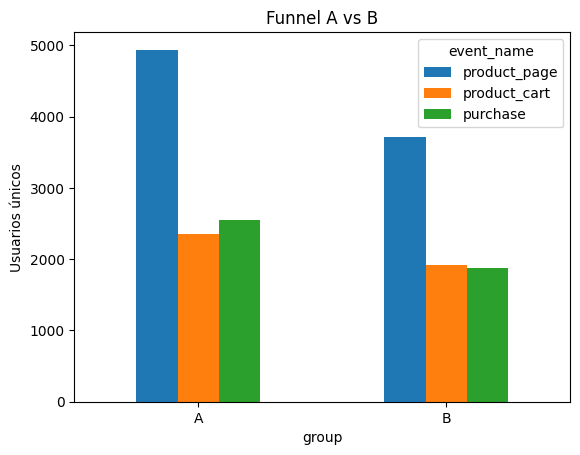

In [100]:
# Visualizar

funnel_pivot[['product_page', 'product_cart', 'purchase']].plot(kind='bar')
plt.title('Funnel A vs B')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=0)
plt.show()

Obs: Visualmente se aprecia que ambos grupos pierden usuarios en cada etapa, y que la ventaja de B no es consistente, es decir no logra un impacto claro sobre A.

In [101]:
# Test por estapas del embudo

# éxitos
success = [
    funnel_pivot.loc['A', 'purchase'],
    funnel_pivot.loc['B', 'purchase']
]

# totales
nobs = [
    funnel_pivot.loc['A', 'product_page'],
    funnel_pivot.loc['B', 'product_page']
]

stat, pval = proportions_ztest(success, nobs)
print(pval)

0.30243982077015075


Obs: p ≥ 0.05 → no hay evidencia estadísticamente significativa de diferencia en conversiones totales entre A y B.

In [102]:
# Diferencia entre grupos

conv_A = funnel_pivot.loc['A', 'purchase'] / funnel_pivot.loc['A', 'product_page']
conv_B = funnel_pivot.loc['B', 'purchase'] / funnel_pivot.loc['B', 'product_page']

diff = conv_B - conv_A

print(diff)

-0.011195055001225418


Obs: diff = -0.011 → B tiene una conversión ligeramente menor que A en la ruta completa.
Confirma que el cambio implementado en B no mejora el embudo.

PASO 4- Ejecución de la prueba A/B

In [103]:

# Éxitos (usuarios que compraron)
success = [
    2555,  # grupo A
    1881   # grupo B
]

# Totales (usuarios que llegaron a product_page)
nobs = [
    4937,  # grupo A
    3715   # grupo B
]

# Z-test para proporciones
stat, pval = proportions_ztest(success, nobs)
print(f"p-value: {pval}")

# Conversiones de cada grupo
conv_A = success[0] / nobs[0]
conv_B = success[1] / nobs[1]

# Diferencia entre B y A
diff = conv_B - conv_A
print(f"Conversión A: {conv_A:.3f}, Conversión B: {conv_B:.3f}, Diferencia (B-A): {diff:.3f}")

p-value: 0.30243982077015075
Conversión A: 0.518, Conversión B: 0.506, Diferencia (B-A): -0.011


Conclusión: El grupo B no logra mejorar la conversión total frente a A. Las diferencias observadas no son significativas, y las anomalías del diseño experimental limitan la confiabilidad de los resultados. El cambio probado no cumple con el objetivo de +10% en el funnel

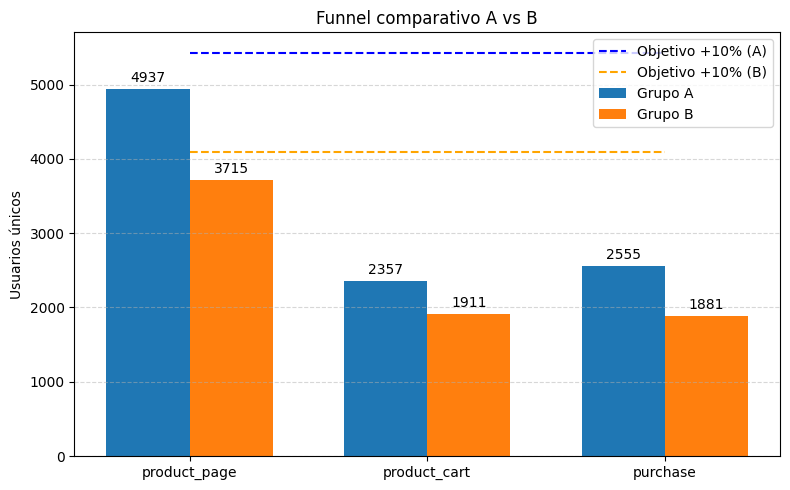

In [104]:


# Datos del funnel
etapas = ['product_page', 'product_cart', 'purchase']
usuarios_A = [4937, 2357, 2555]  # A: usuarios únicos por etapa
usuarios_B = [3715, 1911, 1881]  # B: usuarios únicos por etapa

# Tasa objetivo +10% sobre product_page (ejemplo)
objetivo_A = [usuarios_A[0]*1.10]*3
objetivo_B = [usuarios_B[0]*1.10]*3

x = np.arange(len(etapas))  # posiciones para las barras
width = 0.35  # ancho de las barras

# Crear gráfico de barras
fig, ax = plt.subplots(figsize=(8,5))

bar1 = ax.bar(x - width/2, usuarios_A, width, label='Grupo A', color='#1f77b4')
bar2 = ax.bar(x + width/2, usuarios_B, width, label='Grupo B', color='#ff7f0e')

# Línea de objetivo +10%
ax.plot(x, objetivo_A, '--', color='blue', label='Objetivo +10% (A)')
ax.plot(x, objetivo_B, '--', color='orange', label='Objetivo +10% (B)')

# Etiquetas y título
ax.set_ylabel('Usuarios únicos')
ax.set_title('Funnel comparativo A vs B')
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar valores encima de cada barra
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

Obs: El grupo B no supera a A en etapas críticas del funnel, no alcanza el objetivo de +10% y las diferencias no son significativas; por ello, no se recomienda implementar el cambio.

In [ ]:
# Revisión final

# Supongamos que tu DataFrame final se llama ab_full_data
# Columnas: user_id, event_name, group (A/B), details

# 1️⃣ Conteo de usuarios por grupo despues de duplicados
usuarios_por_grupo = ab_full_data.groupby('group')['user_id'].nunique()
print("Usuarios por grupo:")
print(usuarios_por_grupo, "\n")

# 2️⃣ Conteo de compras por grupo
compras_por_grupo = ab_full_data[ab_full_data['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()
print("Usuarios que compraron por grupo:")
print(compras_por_grupo, "\n")

# 3️⃣ Tasa de conversión por grupo
tasa_conversion = (compras_por_grupo / usuarios_por_grupo) * 100
print("Tasa de conversión (%) por grupo:")
print(tasa_conversion, "\n")

# 4️⃣ Métricas monetarias (promedio y total de 'details')
# Ignorando NaN para promedio, sumando solo valores disponibles
monetario = ab_full_data[ab_full_data['event_name'] == 'purchase'].groupby('group')['details'].agg(['mean','sum','count'])
print("Métricas monetarias por grupo (mean, sum, count de detalles registrados):")
print(monetario, "\n")

# 5️⃣ Opcional: Imputar NaN como 0 si quieres sumar todo como total monetario
ab_full_data['details_filled'] = ab_full_data['details'].fillna(0)
total_ventas = ab_full_data.groupby('group')['details_filled'].sum()
print("Total ventas considerando NaN como $0:")
print(total_ventas)

Usuarios por grupo:
group
A    7433
B    5764
Name: user_id, dtype: int64 

Usuarios que compraron por grupo:
group
A    2555
B    1881
Name: user_id, dtype: int64 

Tasa de conversión (%) por grupo:
group
A    34.373739
B    32.633588
Name: user_id, dtype: float64 

Métricas monetarias por grupo (mean, sum, count de detalles registrados):
            mean        sum  count
group                             
A      23.843560  188221.06   7894
B      23.282451  134782.11   5789 

Total ventas considerando NaN como $0:
group
A    188221.06
B    134782.11
Name: details_filled, dtype: float64


Obs final: El grupo A muestra una tasa de conversión ligeramente superior (34.37% vs 32.63%) y mayores ingresos totales que el grupo B.
Los tamaños de muestra son suficientemente grandes para asegurar confiabilidad estadística en el análisis del experimento.

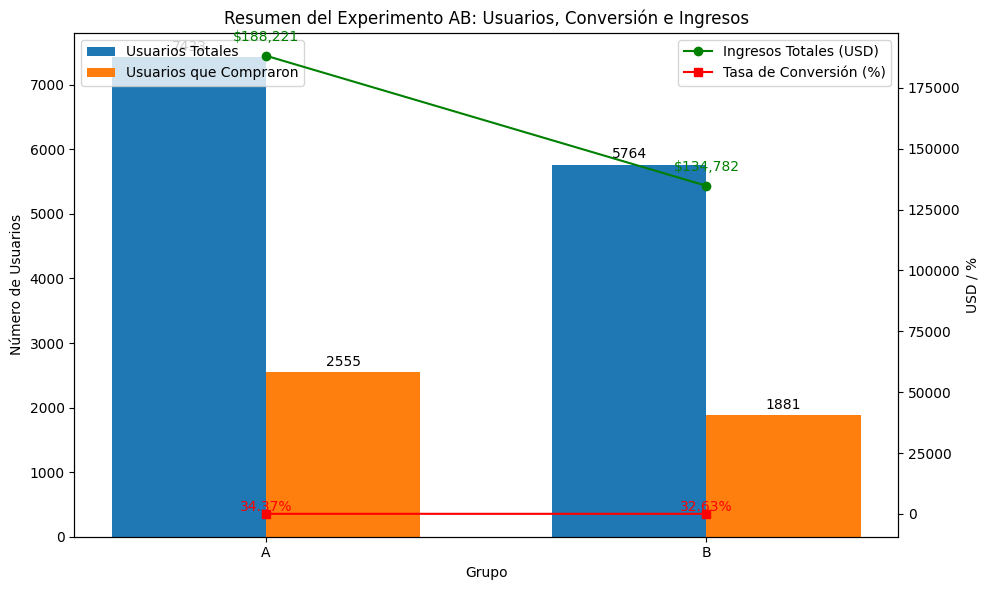

In [106]:

# Datos proporcionados
grupos = ['A', 'B']
usuarios_totales = [7433, 5764]
usuarios_compraron = [2555, 1881]
ingresos_totales = [188221.06, 134782.11]
tasa_conversion = [34.373739, 32.633588]

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(10,6))

# Barras para usuarios que compraron y totales
width = 0.35
x = range(len(grupos))
bars_totales = ax1.bar([i - width/2 for i in x], usuarios_totales, width=width, label='Usuarios Totales', color='#1f77b4')
bars_compraron = ax1.bar([i + width/2 for i in x], usuarios_compraron, width=width, label='Usuarios que Compraron', color='#ff7f0e')

ax1.set_xlabel('Grupo')
ax1.set_ylabel('Número de Usuarios')
ax1.set_xticks(x)
ax1.set_xticklabels(grupos)
ax1.legend(loc='upper left')

# Agregar etiquetas encima de las barras
for bar in bars_totales:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 50, f'{height}', ha='center', va='bottom', fontsize=10)
for bar in bars_compraron:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 50, f'{height}', ha='center', va='bottom', fontsize=10)

# Eje secundario para ingresos y tasa de conversión
ax2 = ax1.twinx()
line_ingresos, = ax2.plot(x, ingresos_totales, color='green', marker='o', label='Ingresos Totales (USD)')
line_conversion, = ax2.plot(x, tasa_conversion, color='red', marker='s', label='Tasa de Conversión (%)')
ax2.set_ylabel('USD / %')
ax2.legend(loc='upper right')

# Agregar etiquetas a las líneas
for i, val in enumerate(ingresos_totales):
    ax2.text(i, val + 5000, f'${val:,.0f}', ha='center', va='bottom', fontsize=10, color='green')
for i, val in enumerate(tasa_conversion):
    ax2.text(i, val + 1, f'{val:.2f}%', ha='center', va='bottom', fontsize=10, color='red')

plt.title('Resumen del Experimento AB: Usuarios, Conversión e Ingresos')
plt.tight_layout()
plt.show()